In [6]:
from IPython.core.interactiveshell import ultratb
# import subprocess
# import sys

# try:
#     from ultralytics import YOLO
# except ModuleNotFoundError:
#     print('ultralytics가 설치되지 않음')
#     try:
#         subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics'])
#     except subprocess.CalledProcessError as e:
#         raise SystemExit(f'ultralytics 설치 실패 : {e}')

#     from ultralytics import YOLO

!pip install ultralytics opencv-python

In [8]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.5/107.7 GB disk)


In [13]:
# YOLO11 모델로 이미지 감지
from ultralytics import YOLO
import ultralytics

print(ultralytics.__version__)

model = YOLO('yolo11n.pt')      # nano version
print(model.names, len(model.names))    # 0000 dataset으로 학습된 모델이므로 라벨 80개가 있다.



8.4.51
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 

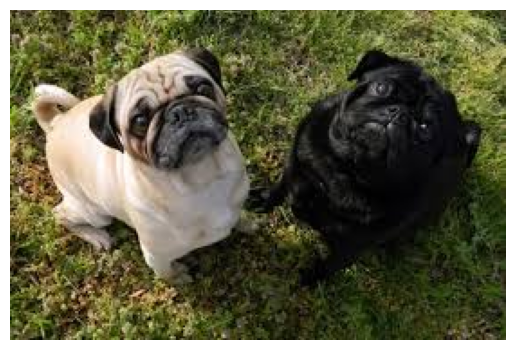


0: 448x640 2 dogs, 393.8ms
Speed: 6.7ms preprocess, 393.8ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)
(183, 275)
image.shape :  (183, 275, 3)
image[0, 0] :  [70 61 30]


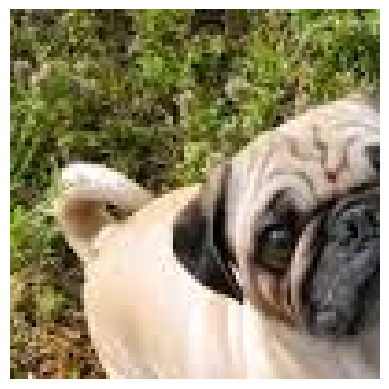

In [22]:
# 이미지 로딩 후 감지
from PIL import Image
import matplotlib.pyplot as plt
import sys

image_path = 'dog.jpg'

try:
    image = Image.open(image_path)
    plt.axis('off')
    plt.imshow(image)
    plt.show()
except Exception as e:
    print(f'load err : {e}')
    sys.exit()

# 객체 감지
import cv2
import numpy as np

try:
    results = model(image)
    # print(results)
    print(results[0].orig_shape)
except Exception as e:
    print('inference : {e}')
    sys.exit()

image = np.array(image)   # Pilow 이미지 -> image.open() -> np.array()하면 (H, W, 3) 형태의 넘파이 배열이 됨
print('image.shape : ', image.shape)
# print('image[:5, :5] : ', image[:5, :5])
print('image[0, 0] : ', image[0, 0])

# 이미지 영역 자르기
cropped = image[:100, :100]
plt.imshow(cropped)
plt.axis('off')
plt.show()

11 21 134 151
dog
box.conf[0] : tensor(0.8854)
confidence :  0.8854234218597412
141 22 261 149
dog
box.conf[0] : tensor(0.5285)
confidence :  0.5284875631332397
dog_detected : True


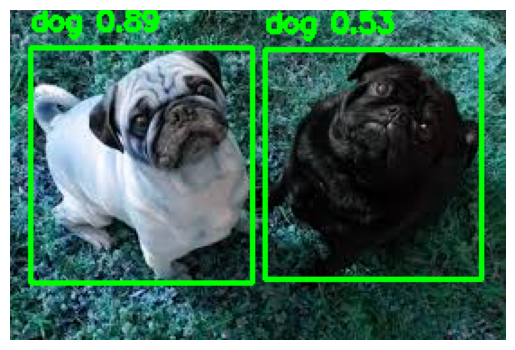

개가 보여요~~~


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# dog 이미지에 박스 채우기
image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

dog_detected = False  # dog감지 여부 판단용 변수

for result in results:
    try:
        for box in result.boxes:     # 감지된 객체들은 바운딩 박스 리스트
            x1, y1, x2, y2 = map(int, box.xyxy[0]) # 좌표
            print(x1, y1, x2, y2)

            label = result.names[int(box.cls[0])]   # 감지된 객체 클래스 이름 얻기
            print(label)

            print('box.conf[0] :', box.conf[0])  # tensor(0.5285)
            confidence = box.conf[0].item()
            print('confidence : ', confidence)

            if label == 'dog' and confidence > 0.4:
                dog_detected = True

            # 바운딩 박스 그리기
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, f'{label} {confidence:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    except Exception as e:
        print(f'process err : {e}')


print('dog_detected :', dog_detected)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

if label == 'dog' and confidence > 0.4:
  print('개가 보여요~~~')

# 감지 결과를  파일로 저장
cv2.imwrite('yolo1out.jpg', image)

# colab에서 저장한 이미지 다운로드할 경우
from google.colab import files
files.download('yolo1out.jpg')
